# ANN Project: Audio Classification with CNN and RNN

## Project Overview

For students who select the ANN project track, the goal is to classify audio commands from the **Google Speech Commands dataset** using both Convolutional Neural Networks (CNN) and Recurrent Neural Networks (RNN), and compare their robustness to varying levels of background "noise" sampled from another dataset.

#### Project Members
- Rasmus Kebert
- Sebastian Petterson
- Monika Shrivastava
- Abhay Soni
- Viggo Härdelin

## Datasets

### Google Speech Commands Dataset
The [Google Speech Commands dataset](https://pytorch.org/audio/stable/generated/torchaudio.datasets.SPEECHCOMMANDS.html) is a collection of short (1 second) audio clips of spoken words. The dataset contains 65,000 utterances of 30 short words by thousands of different speakers. Each audio file is sampled at 16 kHz.

**Dataset characteristics:**
- Sample rate: 16 kHz
- Duration: 1 second per clip
- Number of classes: 30 words (e.g., "yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", etc.)
- Total samples: ~65,000

**How to access:** The dataset can be loaded directly using `torchaudio.datasets.SPEECHCOMMANDS` or downloaded from the [official repository](http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz).

### ESC-50: Environmental Sound Classification
The [ESC-50 dataset](https://github.com/karolpiczak/ESC-50) contains 2,000 environmental audio recordings organized into 50 classes (40 clips per class). For this project, you will use sounds from this dataset as background noise to test the robustness of your models.

**Dataset characteristics:**
- Sample rate: 44.1 kHz (needs resampling to 16 kHz before combining with a speech command)
- Duration: 5 seconds per clip
- Categories include: rain, sea waves, crackling fire, clock tick, dog bark, footsteps, door knock, etc.

**How to access:** Download from the [ESC-50 GitHub repository](https://github.com/karolpiczak/ESC-50).

## Project Task

### Objective
Compare the performance of CNN and RNN architectures for speech command classification under different levels of background noise. The models should have a similar number of trainable parameters to ensure a fair comparison.

### Requirements

#### 1. Data Preprocessing
- **Resample** the ESC-50 background sounds from 44.1 kHz to **16 kHz** to match the Google Speech Commands sample rate
- Create augmented versions of the Speech Commands dataset by mixing in background noise at different signal-to-noise ratios

In [ ]:
import random

from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import torch
import torchaudio
import os
from torchaudio.datasets import SPEECHCOMMANDS
from torch.utils.data import DataLoader, random_split, Dataset
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torchaudio.transforms import Resample
import torchaudio
# Running with gpu otherwise it takes ages
if torch.cuda.is_available():
    gpu = torch.device("cuda")  # Nvidia GPU
elif torch.backends.mps.is_available():
    gpu = torch.device("mps") # Mac Supported GPU
else:
    gpu = torch.device("cpu")   # Fallback to CPU

print(f"Using device: {gpu}")
# To enable confusion matrix to render and then continue
plt.ion()

In [2]:
train_dataset = SPEECHCOMMANDS(
    root='./', 
    url='speech_commands_v0.01', 
    download=True,
    subset="training"
)


val_dataset = SPEECHCOMMANDS(
    root='./', 
    url='speech_commands_v0.01', 
    download=True,
    subset="validation"
)


test_dataset = SPEECHCOMMANDS(
    root='./', 
    url='speech_commands_v0.01', 
    download=True,
    subset="testing"
)

#### Desciption for getting background noise
Go to github repository `https://github.com/karolpiczak/ESC-50`

Download it, take out directory audio and change name of it to noise_audio. Then run the file. Dataset size should be

```
Dataset size: 1400
Dataset size: 300
Dataset size: 300
Dataset size: 51088
Dataset size: 6798
Dataset size: 6835
```

In [3]:
PATH_ESC50 = "./noise_audio"

noise_files = []

for i in os.listdir(PATH_ESC50):
    if os.path.exists("noise_audio/" + i):
        noise_files.append("noise_audio/" + i)


dataset = noise_files
lengths = [int(len(dataset)*0.7), int(len(dataset)*0.15), len(dataset)-int(len(dataset)*0.7)-int(len(dataset)*0.15)]
train_dataset_noise, val_dataset_noise, test_dataset_noise = random_split(dataset, lengths)

train_loader_noise = DataLoader(train_dataset_noise, batch_size=64, shuffle=True)
val_loader_noise = DataLoader(val_dataset_noise, batch_size=64, shuffle=False)
test_loader_noise = DataLoader(test_dataset_noise, batch_size=64, shuffle=False)


print(f"Dataset size: {len(train_dataset_noise)}")
print(f"Dataset size: {len(val_dataset_noise)}")
print(f"Dataset size: {len(test_dataset_noise)}")
print(f"Dataset size: {len(train_dataset)}")
print(f"Dataset size: {len(val_dataset)}")
print(f"Dataset size: {len(test_dataset)}")

Dataset size: 1400
Dataset size: 300
Dataset size: 300
Dataset size: 51088
Dataset size: 6798
Dataset size: 6835


#### 2. Noise Mixing
Evaluate classification accuracy on the Speech Commands dataset with **three noise levels** based on signal RMS (Root Mean Square):

- **0% noise:** Clean speech commands audio (no background noise added)
- **10% noise:** RMS of background noise = 10% of speech command RMS
- **50% noise:** RMS of background noise = 50% of speech command RMS (i.e., equal signal and noise power)

The RMS mixing ensures consistent and measurable noise levels across all experiments.

In [4]:
SPEECH_LEN = 16000
NOISE_HZ = 44100
NOISE_FULL = 220500

#add noise to the speech with rms level 0, 10 or 50:
def add_rms_noise(speech, noise_level):
    if noise_level == 0:
        if speech.shape[1] < SPEECH_LEN:
            speech = F.pad(speech, (0, SPEECH_LEN - speech.shape[1]))
        speech_rms = torch.sqrt(torch.mean(speech**2))
        noise_rms = torch.zeros(speech_rms.shape)
        return speech , speech_rms, noise_rms
    #pick a random noise file from the noise dataset, load it, and resample it to 16kHz
    random_noise = random.choice(noise_files)
    noise , sr = torchaudio.load(random_noise)
    resample = Resample(orig_freq=sr, new_freq=16000)
    noise_16k = resample(noise)
    if speech.shape[1] < SPEECH_LEN:
        speech = F.pad(speech, (0, SPEECH_LEN - speech.shape[1]))

    #Shorten the noise to match the speech length if it's longer, or pad it if it's shorter
    if noise_16k.shape[1] >= speech.shape[1]:
        start = random.randint(0, noise_16k.shape[1] - speech.shape[1])
        noise_16k_1s = noise_16k[:, start:start+speech.shape[1]]
    else:
        noise_16k_1s = F.pad(noise_16k, (0, speech.shape[1] - noise_16k.shape[1]))
    
    #adding noise to the speech with the specified noise level
    speech_rms = torch.sqrt(torch.mean(speech**2))
    noise_rms = torch.sqrt(torch.mean(noise_16k_1s**2))
    
    scale = (noise_level * speech_rms) / (noise_rms + 1e-10)
    scaled_noise = noise_16k_1s * scale
    noisy_speech = speech + scaled_noise
    return noisy_speech, speech_rms, noise_rms

In [5]:
all_labels = []


#get all labels and create a list of unique labels, then assign an id to each label based on its index in the list of unique labels
for i in range(len(train_dataset)):
    all_labels.append(train_dataset[i][2])

labels = sorted(set(all_labels))

print(labels)

['bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'four', 'go', 'happy', 'house', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'wow', 'yes', 'zero']


In [6]:
class NoisyDataset(Dataset):
    def __init__(self, dataset, noise_level):
        self.dataset = dataset
        self.noise_level = noise_level

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        speech,sr, label, _, _  = self.dataset[idx]
        noisy_speech, _, _ = add_rms_noise(speech, self.noise_level)
        label_id = 0 
        for i, label_name in enumerate(labels):
            if label_name == label:
                label_id = i
                break
        return noisy_speech, label_id

In [7]:
"""train_noise_10 = NoisyDataset(train_dataset, noise_level=0.1)
train_noise_50 = NoisyDataset(train_dataset, noise_level=0.5)

val_noise_0 = NoisyDataset(val_dataset, noise_level=0.0)
val_noise_10 = NoisyDataset(val_dataset, noise_level=0.1)
val_noise_50 = NoisyDataset(val_dataset, noise_level=0.5)

test_noise_0 = NoisyDataset(test_dataset, noise_level=0.0)
test_noise_10 = NoisyDataset(test_dataset, noise_level=0.1)
test_noise_50 = NoisyDataset(test_dataset, noise_level=0.5)
"""


#train_noise_loader_0 = DataLoader(train_noise_0, batch_size=1, shuffle=True) #speech and labels with noise level 0.0
""" 

train_noisy_loader_10 = DataLoader(train_noisy_10, batch_size=1, shuffle=True)
train_noisy_loader_50 = DataLoader(train_noisy_50, batch_size=1, shuffle=True)

val_noisy_loader_0 = DataLoader(val_noisy_0, batch_size=1, shuffle=False)
val_noisy_loader_10 = DataLoader(val_noisy_10, batch_size=1, shuffle=False)
val_noisy_loader_50 = DataLoader(val_noisy_50, batch_size=1, shuffle=False)

test_noisy_loader_0 = DataLoader(test_noisy_0, batch_size=1, shuffle=False)
test_noisy_loader_10 = DataLoader(test_noisy_10, batch_size=1, shuffle=False)
test_noisy_loader_50 = DataLoader(test_noisy_50, batch_size=1, shuffle=False)
 """

' \n\ntrain_noisy_loader_10 = DataLoader(train_noisy_10, batch_size=1, shuffle=True)\ntrain_noisy_loader_50 = DataLoader(train_noisy_50, batch_size=1, shuffle=True)\n\nval_noisy_loader_0 = DataLoader(val_noisy_0, batch_size=1, shuffle=False)\nval_noisy_loader_10 = DataLoader(val_noisy_10, batch_size=1, shuffle=False)\nval_noisy_loader_50 = DataLoader(val_noisy_50, batch_size=1, shuffle=False)\n\ntest_noisy_loader_0 = DataLoader(test_noisy_0, batch_size=1, shuffle=False)\ntest_noisy_loader_10 = DataLoader(test_noisy_10, batch_size=1, shuffle=False)\ntest_noisy_loader_50 = DataLoader(test_noisy_50, batch_size=1, shuffle=False)\n '

#### 3. Model Implementation
Implement and train two model architectures:

**a) Convolutional Neural Network (CNN)**
- Process audio spectrograms (e.g., Mel-spectrograms, MFCCs) as 2D images
- Use convolutional layers to extract features from time-frequency representations

**b) Recurrent Neural Network (RNN)**
- Process raw audio waveforms or frame-based features sequentially
- Use LSTM or GRU layers to capture temporal dependencies

**Important:** Both models should have approximately the same number of parameters for a fair comparison.

In [8]:
# CNN Model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 13 * 5, 120)
        self.fc2 = nn.Linear(120, 30)

    def forward(self, x):
        # Implement the forward function in the network
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

LEARNING_RATE = 1e-3

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [9]:
# CNN - Train and Test functions
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs):
    min_LSTM_loss = 10
    
    model.train()
    melspectogram = torchaudio.transforms.MelSpectrogram(sample_rate=16000,n_fft=1024,hop_length=512,n_mels=64).to(gpu)

    for i in range(num_epochs):
        epoch_training_loss = 0
        epoch_validation_loss = 0

        model.train()
        correct = 0
        total = 0
        for waveform, targets in train_loader:
            waveform = waveform.to(gpu)
            targets = targets.to(gpu)

            mel2D = melspectogram(waveform)

            mel2D = torch.log(mel2D + 1e-9)
            # Forward pass
            prediction = model(mel2D)
            loss = criterion(prediction, targets)

            optimizer.zero_grad()
            loss.backward()

            optimizer.step()

            

            guess = torch.argmax(prediction, dim=-1)
            for i in range(len(targets)):
                if guess[i].item() == targets[i].item():
                    correct += 1
                total += 1
        epoch_training_loss += loss.item()  
        print("Training accuracy: ", correct/total)
            
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for waveform, targets in val_loader:
                waveform = waveform.to(gpu)
                targets = targets.to(gpu)
                
                mel2D = melspectogram(waveform)

                mel2D = torch.log(mel2D + 1e-9)
                
                # Forward pass
                prediction = model(mel2D)
                loss = criterion(prediction, targets)
                epoch_validation_loss += loss.item()
            
                

                guess = torch.argmax(prediction, dim=-1)
                for i in range(len(targets)):
                    if guess[i].item() == targets[i].item():
                        correct += 1
                    total += 1   
        epoch_validation_loss /= len(val_loader)
        if epoch_validation_loss<min_LSTM_loss:
            min_LSTM_loss = epoch_validation_loss
            torch.save(model, 'best_model.pt')
        print("validation accuracy: ", correct/total)
                    
    return torch.load("best_model.pt", weights_only=False)

In [ ]:
# Test function
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    preds = []
    lbs = []
    melspectogram = torchaudio.transforms.MelSpectrogram(sample_rate=16000,n_fft=1024,hop_length=512,n_mels=64).to(gpu)

    with torch.no_grad():
        for waveform, targets in test_loader:
            waveform = waveform.to(gpu)
            targets = targets.to(gpu)

            mel2D = melspectogram(waveform)

            mel2D = torch.log(mel2D + 1e-9)

            prediction = model(mel2D)

            guess = torch.argmax(prediction, dim=-1)
            for i in range(len(targets)):
                if guess[i].item() == targets[i].item():
                    correct += 1
                total += 1
                preds.append(guess[i].item())
                lbs.append(targets[i].item())

    accuracy = correct/total

    conf_mat = confusion_matrix(lbs, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
    

    disp.plot()
    plt.show()
    plt.pause(0.01)
    return accuracy

#### 4. Performance Metrics
For each model and noise level, report:
- Training accuracy
- Validation accuracy
- Test accuracy
- Confusion matrix

Training accuracy:  0.6512488255559036
validation accuracy:  0.7896440129449838
Training accuracy:  0.8283354212339492
validation accuracy:  0.8227419829361577
Training accuracy:  0.8561305981835264
validation accuracy:  0.8270079435127978
Training accuracy:  0.8730034450360162
validation accuracy:  0.852603706972639
Training accuracy:  0.8806569057312872
validation accuracy:  0.8451015004413063
Training accuracy:  0.8870576260569997
validation accuracy:  0.8499558693733451
Training accuracy:  0.8935757907923583
validation accuracy:  0.8624595469255664
Training accuracy:  0.8985084559974945
validation accuracy:  0.8545160341276846
Training accuracy:  0.9006224553711243
validation accuracy:  0.863047955280965
Training accuracy:  0.9029713435640464
validation accuracy:  0.8623124448367167


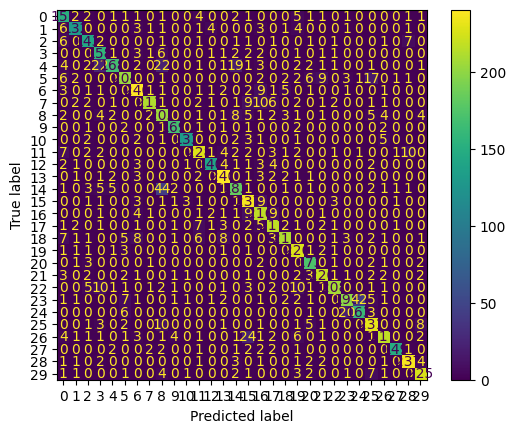

0.8534016093635699
Training accuracy:  0.6412073285311619
validation accuracy:  0.7840541335686967
Training accuracy:  0.8156905731287191
validation accuracy:  0.8145042659605767
Training accuracy:  0.8436227685562168
validation accuracy:  0.8296557811120918
Training accuracy:  0.8572267460068901
validation accuracy:  0.83480435422183
Training accuracy:  0.8665831506420294
validation accuracy:  0.8405413356869668
Training accuracy:  0.8707328531161916
validation accuracy:  0.8418652544866138
Training accuracy:  0.87454979642969
validation accuracy:  0.8493674610179465
Training accuracy:  0.8768791105543376
validation accuracy:  0.8567225654604296
Training accuracy:  0.8801479799561541
validation accuracy:  0.852603706972639
Training accuracy:  0.8825555903538992
validation accuracy:  0.8512797881729921


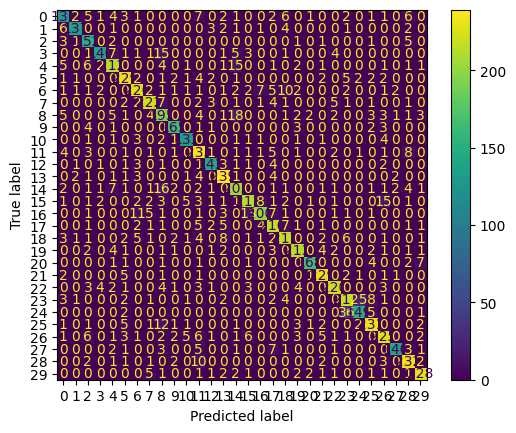

0.8573518653986832
Training accuracy:  0.5282258064516129
validation accuracy:  0.6921153280376582
Training accuracy:  0.7311110241152521
validation accuracy:  0.7380111797587525
Training accuracy:  0.7629384591293454
validation accuracy:  0.7566931450426596
Training accuracy:  0.7794002505480739
validation accuracy:  0.7687555163283318
Training accuracy:  0.7921038208581271
validation accuracy:  0.774786701971168
Training accuracy:  0.7950986533041027
validation accuracy:  0.7746395998823183
Training accuracy:  0.8006576886940182
validation accuracy:  0.7822889085025008
Training accuracy:  0.805629502035703
validation accuracy:  0.7733156810826713
Training accuracy:  0.8036329470717194
validation accuracy:  0.7867019711679906
Training accuracy:  0.809818352646414
validation accuracy:  0.7880258899676376


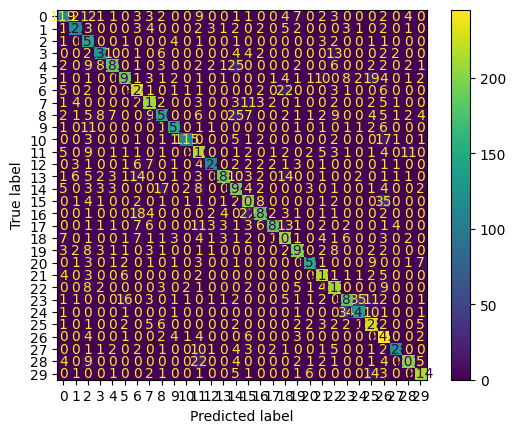

0.7880029261155815


In [11]:
# CNN - Training and evaluation across noise levels
noise_levels = [0,0.1,0.5]

for levels in noise_levels:
    # Load our network
    model = Net().to(gpu)


    # Define our loss function
    criterion = nn.CrossEntropyLoss()

    # Define our optimizer
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
    train_noise_0 = NoisyDataset(train_dataset, noise_level=levels)
    val_noise_0 = NoisyDataset(val_dataset, noise_level=levels)
    test_noise_0 = NoisyDataset(test_dataset, noise_level=levels)

    train_loader = DataLoader(train_noise_0, batch_size=64, shuffle=True)

    val_loader = DataLoader(val_noise_0, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_noise_0, batch_size=64, shuffle=False)

    trained_model = train_model(model, criterion, optimizer, train_loader, val_loader, 10)
    print(test_model(trained_model, test_loader))

### RNN Model

In [ ]:
# RNN Model using LSTM
class RNNNet(nn.Module):
    def __init__(self):
        super(RNNNet, self).__init__()
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(128, 120)
        self.fc2 = nn.Linear(120, 30)

    def forward(self, x):
        # reshape mel spectrogram to (batch, time_steps, mel_features)
        x = x.squeeze(1)
        x = x.permute(0, 2, 1)

        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]

        x = F.relu(self.fc1(last_hidden))
        x = self.fc2(x)
        return x

cnn_model = Net()
rnn_model = RNNNet()

cnn_params = sum(p.numel() for p in cnn_model.parameters())
rnn_params = sum(p.numel() for p in rnn_model.parameters())

print(f"CNN parameters: {cnn_params}")
print(f"RNN parameters: {rnn_params}")

BATCH_SIZE_RNN = 512 # change to 512 for RNN, 64 for CNN

In [ ]:
# RNN version of train_model - saves to best_rnn_model so it doesnt overwrite the CNN one
def train_model_rnn(model, criterion, optimizer, train_loader, val_loader, num_epochs, noise_level=0):
    min_LSTM_loss = 10
    save_path = f'best_rnn_model_{noise_level}.pt'
    
    model.train()
    melspectogram = torchaudio.transforms.MelSpectrogram(sample_rate=16000,n_fft=1024,hop_length=512,n_mels=64).to(gpu)

    for i in range(num_epochs):
        epoch_training_loss = 0
        epoch_validation_loss = 0

        model.train()
        correct = 0
        total = 0
        for waveform, targets in train_loader:
            waveform = waveform.to(gpu)
            targets = targets.to(gpu)

            mel2D = melspectogram(waveform)

            mel2D = torch.log(mel2D + 1e-9)
            # Forward pass
            prediction = model(mel2D)
            loss = criterion(prediction, targets)

            optimizer.zero_grad()
            loss.backward()

            optimizer.step()

            guess = torch.argmax(prediction, dim=-1)
            for i in range(len(targets)):
                if guess[i].item() == targets[i].item():
                    correct += 1
                total += 1
        epoch_training_loss += loss.item()  
        print("Training accuracy: ", correct/total)
            
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for waveform, targets in val_loader:
                waveform = waveform.to(gpu)
                targets = targets.to(gpu)
                
                mel2D = melspectogram(waveform)

                mel2D = torch.log(mel2D + 1e-9)
                
                # Forward pass
                prediction = model(mel2D)
                loss = criterion(prediction, targets)
                epoch_validation_loss += loss.item()
            
                

                guess = torch.argmax(prediction, dim=-1)
                for i in range(len(targets)):
                    if guess[i].item() == targets[i].item():
                        correct += 1
                    total += 1   
        epoch_validation_loss /= len(val_loader)
        if epoch_validation_loss<min_LSTM_loss:
            min_LSTM_loss = epoch_validation_loss
            torch.save(model, save_path)
        print("validation accuracy: ", correct/total)
                    
    return torch.load(save_path, weights_only=False)

In [ ]:
# RNN - Training across noise levels
noise_levels = [0, 0.1, 0.5]

for levels in noise_levels:
    model = RNNNet().to(gpu)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)

    train_noise_rnn = NoisyDataset(train_dataset, noise_level=levels)
    val_noise_rnn = NoisyDataset(val_dataset, noise_level=levels)

    train_loader = DataLoader(train_noise_rnn, batch_size=BATCH_SIZE_RNN, shuffle=True)
    val_loader = DataLoader(val_noise_rnn, batch_size=BATCH_SIZE_RNN, shuffle=False)

    trained_rnn = train_model_rnn(model, criterion, optimizer, train_loader, val_loader, 10, noise_level=levels)

In [ ]:
# RNN - Testing across noise levels (run separately so we dont have to retrain)
noise_levels = [0, 0.1, 0.5]
rnn_accuracies = []

for levels in noise_levels:
    trained_rnn = torch.load(f'best_rnn_model_{levels}.pt', weights_only=False)
    trained_rnn.to(gpu)

    test_noise_rnn = NoisyDataset(test_dataset, noise_level=levels)
    test_loader = DataLoader(test_noise_rnn, batch_size=BATCH_SIZE_RNN, shuffle=False)

    acc = test_model(trained_rnn, test_loader)
    rnn_accuracies.append(acc)
    print(f"RNN Test accuracy at {int(levels*100)}% noise: {acc}")

In [ ]:
# Comparison plot : accuracy vs noise level for both models
# Fill in CNN accuracies from the CNN training output above
cnn_accuracies = [0.0, 0.0, 0.0]  # TODO: fill in after running CNN test for 0%, 10%, 50%

noise_labels = ['0%', '10%', '50%']
x = range(len(noise_labels))

plt.figure(figsize=(8, 5))
plt.plot(x, cnn_accuracies, 'o-', label='CNN')
plt.plot(x, rnn_accuracies, 's-', label='RNN (LSTM)')
plt.xticks(list(x), noise_labels)
plt.xlabel('Noise Level')
plt.ylabel('Test Accuracy')
plt.title('CNN vs RNN - Test Accuracy at Different Noise Levels')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.show()

#### 5. Minimum Accuracy Requirement
Your models should achieve **at least 75% test accuracy** on the clean (0% noise) Speech Commands dataset. This ensures that your baseline model is working correctly before evaluating noise robustness.

#### 6. Analysis
Compare and discuss:
- Which architecture (CNN or RNN) performs better at each noise level?
- How does performance degrade as noise increases?
- What are the computational trade-offs between the two approaches?
- Which types of commands are most/least robust to noise?

### Optional challenge (deepening)
Can you combine CNN and RNN to make one model that performs better in terms of accuracy versus total parameter count? Which type of model performs best at very high noise level? What level of noise is too high for reliable classification?

## Key Resources

### PyTorch Documentation
- **[torchaudio.datasets.SPEECHCOMMANDS](https://pytorch.org/audio/stable/generated/torchaudio.datasets.SPEECHCOMMANDS.html)** - Official documentation for loading the Speech Commands dataset
- **[torchaudio.transforms](https://pytorch.org/audio/stable/transforms.html)** - Audio transformations including MelSpectrogram, MFCC, and Resample
- **[PyTorch LSTM Documentation](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)** - For implementing RNN models
- **[PyTorch Conv2d Documentation](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)** - For implementing CNN models

### Useful Libraries
- **torchaudio**: For audio loading, transformations (Mel-spectrogram, MFCC, resampling), and the SPEECHCOMMANDS dataset
- **torch.nn**: For building CNN (Conv2d, MaxPool2d) and RNN (LSTM, GRU) architectures
- **librosa**: Alternative library for audio feature extraction and processing
- **numpy**: For signal processing, RMS calculations, and noise mixing

## Getting Started

1. **Load the datasets**: Use `torchaudio.datasets.SPEECHCOMMANDS` for speech commands and download ESC-50 from GitHub
2. **Explore the data**: Understand audio formats, sample rates, and class distributions
3. **Implement preprocessing**: Create a pipeline for resampling ESC-50 sounds and mixing noise at different RMS levels
4. **Design CNN architecture**: Start with a model that processes Mel-spectrograms or MFCCs as 2D images
5. **Design RNN architecture**: Build an LSTM/GRU model with similar parameter count that processes sequential audio features
6. **Train on clean data**: Ensure both models achieve at least 75% accuracy before adding noise
7. **Evaluate on noisy data**: Test both models on 10% and 50% noise levels
8. **Analyze and compare**: Create plots and confusion matrices to compare model performance

## Submission

Your project submission should include:
- Complete Jupyter notebook with all code, visualizations, and analysis
- Clear documentation of your model architectures (number of parameters for each)
- Performance comparison plots (accuracy vs. noise level for both models)
- Confusion matrices for at least the 0%, 10% and 50% noise conditions
- Discussion of results and conclusions